In [1]:
%store -r bar_data_HIST_TRMM19852014_minus_TRMM 
# stored in 20260227_JJAS_NDJF_PR_BIAS-HIST-TRMM.ipynb

%store -r bar_data_G6sulfur20212100_minus_HIST19212000
%store -r bar_data_SSP58520212100_minus_HIST19212000
%store -r bar_data_SSP24520212100_minus_HIST19212000

%store -r bar_data_G6sulfur20212100_minus_SSP24520212100
%store -r bar_data_G6sulfur20212100_minus_SSP58520212100



Available labels: ['Land', 'Ocean', 'N. America', 'S. America', 'Sahel', 'S. Africa', 'India', 'N. Australia']


/tmp/ipykernel_1695/3343030317.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.scatter(np.full(len(pm), float(x + offset)), pm,


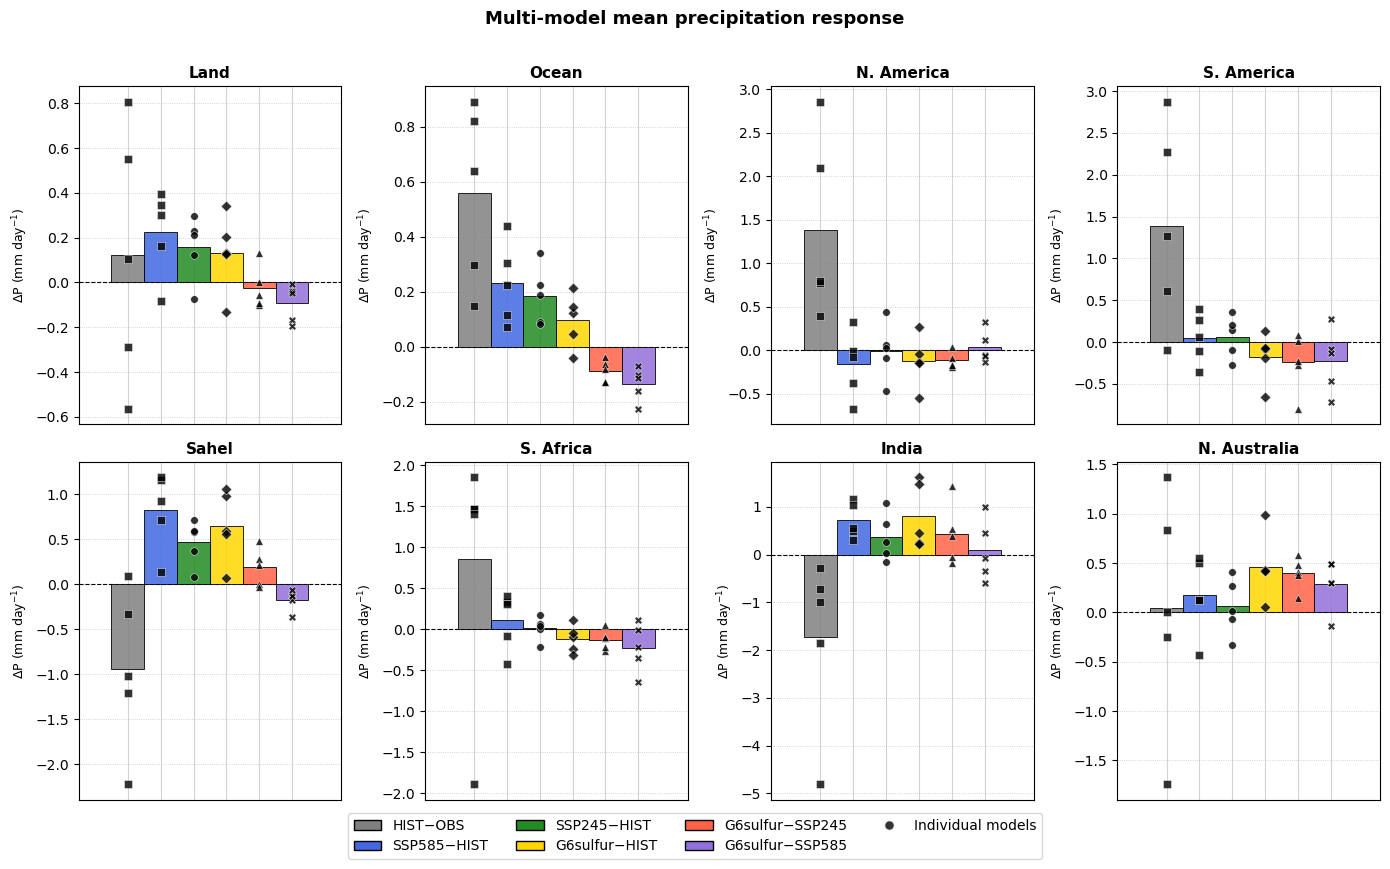

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# # ── pull named datasets from the single store dict ──────────────────────────
# bar_HIST_TRMM       = all_bar_data['bar_data_HIST19852014_minus_TRMM']
# bar_SSP585_HIST     = all_bar_data['bar_data_SSP58520212100_minus_HIST19212000']
# bar_SSP245_HIST     = all_bar_data['bar_data_SSP24520212100_minus_HIST19212000']
# bar_G6s_HIST        = all_bar_data['bar_data_G6sulfur20212100_minus_HIST19212000']
# bar_G6s_SSP245      = all_bar_data['bar_data_G6sulfur20212100_minus_SSP24520212100']
# bar_G6s_SSP585      = all_bar_data['bar_data_G6sulfur20212100_minus_SSP58520212100']

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

width   = 0.15
offsets = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * width

bar_color = ['gray', 'royalblue', 'forestgreen', 'gold', 'tomato', 'mediumpurple']

# datasets = [
#     (bar_HIST_TRMM,   offsets[0], 's', bar_color[0], 'HIST−OBS'),
#     (bar_SSP585_HIST, offsets[1], 's', bar_color[1], 'SSP585−HIST'),   # fixed label
#     (bar_SSP245_HIST, offsets[2], 'o', bar_color[2], 'SSP245−HIST'),   # fixed label
#     (bar_G6s_HIST,    offsets[3], 'D', bar_color[3], 'G6sulfur−HIST'),
#     (bar_G6s_SSP245,  offsets[4], '^', bar_color[4], 'G6sulfur−SSP245'),
#     (bar_G6s_SSP585,  offsets[5], 'X', bar_color[5], 'G6sulfur−SSP585'),
# ]

datasets = [
    (bar_data_HIST_TRMM19852014_minus_TRMM,          offsets[0], 's', bar_color[0],   'HIST-OBS'),
    
    (bar_data_SSP58520212100_minus_HIST19212000,     offsets[1], 's', bar_color[1],   'SSP245−HIST'),
    (bar_data_SSP24520212100_minus_HIST19212000,     offsets[2], 'o', bar_color[2],   'SSP585−HIST'),
    (bar_data_G6sulfur20212100_minus_HIST19212000,   offsets[3], 'D', bar_color[3],   'G6sulfur−HIST'),
    (bar_data_G6sulfur20212100_minus_SSP24520212100, offsets[4], '^', bar_color[4],   'G6sulfur−SSP245'),
    (bar_data_G6sulfur20212100_minus_SSP58520212100, offsets[5], 'X', bar_color[5],   'G6sulfur−SSP585'),
]

panel_layout = [
    (0, 0, 'Land'),
    (0, 1, 'Ocean'),
    (0, 2, 'N. America'),
    (0, 3, 'S. America'),
    (1, 0, 'Sahel'),
    (1, 1, 'S. Africa'),
    (1, 2, 'India'),
    (1, 3, 'N. Australia'),
]

# Use any dataset to get label order — they're all the same
all_labels = bar_data_HIST_TRMM19852014_minus_TRMM['labels']
print("Available labels:", all_labels)

rng = np.random.default_rng(42)
x   = np.array([0])

for row, col, panel_label in panel_layout:
    ax = axes[row, col]

    try:
        i_label = list(all_labels).index(panel_label)
    except ValueError:
        ax.set_visible(False)
        print(f"Label '{panel_label}' not found, skipping")
        continue

    # Gray vertical guide lines at each bar center
    for offset in offsets:
        ax.axvline(x + offset, color='lightgray', linewidth=0.8,
                   linestyle='-', zorder=1)

    for data, offset, marker, color, leg_label in datasets:
        val = data['means'][i_label]
        ax.bar(x + offset, val, width=width,
               color=color, edgecolor='k', linewidth=0.7,
               alpha=0.85, zorder=3)

        pm = data['per_model_all'][i_label]
        ax.scatter(np.full(len(pm), float(x + offset)), pm,
                   marker=marker, color='k', s=30, zorder=5,
                   alpha=0.8, edgecolors='white', linewidths=0.4)

    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', zorder=2)
    ax.set_xticks([])
    ax.set_xlim(-0.6, 0.6)
    ax.set_title(panel_label, fontsize=11, fontweight='bold')
    ax.set_ylabel('$\\Delta$P (mm day$^{-1}$)', fontsize=9)
    ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7, zorder=2)

# Shared legend
legend_patches = [
    mpatches.Patch(facecolor=bar_color[0], edgecolor='k', label='HIST−OBS'),
    mpatches.Patch(facecolor=bar_color[1], edgecolor='k', label='SSP585−HIST'),
    mpatches.Patch(facecolor=bar_color[2], edgecolor='k', label='SSP245−HIST'),
    mpatches.Patch(facecolor=bar_color[3], edgecolor='k', label='G6sulfur−HIST'),
    mpatches.Patch(facecolor=bar_color[4], edgecolor='k', label='G6sulfur−SSP245'),
    mpatches.Patch(facecolor=bar_color[5], edgecolor='k', label='G6sulfur−SSP585'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
               markersize=7, alpha=0.8, label='Individual models'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.06))

plt.suptitle('Multi-model mean precipitation response',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("Rainfall_change_panels.png", dpi=150, bbox_inches="tight")
plt.show()

# Plotting all together 
    Rainfall
    MSEsfc
    Contribution of T to MSEsfc
    Contribution of T to MSEsfc

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle
from pathlib import Path

# ── Load MSE data ────────────────────────────────────────────────────────────
SAVE_DIR = Path('/home/users/bidyut/UoE/20260218_Monsoons')
with open(SAVE_DIR / 'all_bar_data_Relative.pkl', 'rb') as f:
    all_bar_data = pickle.load(f)

# ── Load MSE_T data ────────────────────────────────────────────────────────────
with open(SAVE_DIR / 'all_bar_data_Relative_T.pkl', 'rb') as ft:
    all_bar_data_T = pickle.load(ft)

# ── Load MSE_Q data ────────────────────────────────────────────────────────────
with open(SAVE_DIR / 'all_bar_data_Relative_Q.pkl', 'rb') as fq:
    all_bar_data_Q = pickle.load(fq)

bar_MSE_SSP585_HIST  = all_bar_data['MSEsfc_bar_data_SSP58520212100_minus_HIST19212000']
bar_MSE_SSP245_HIST  = all_bar_data['MSEsfc_bar_data_SSP24520212100_minus_HIST19212000']
bar_MSE_G6s_HIST     = all_bar_data['MSEsfc_bar_data_G6sulfur20212100_minus_HIST19212000']
bar_MSE_G6s_SSP245   = all_bar_data['MSEsfc_bar_data_G6sulfur20212100_minus_SSP24520212100']
bar_MSE_G6s_SSP585   = all_bar_data['MSEsfc_bar_data_G6sulfur20212100_minus_SSP58520212100']

# Load T contribution to MSEsfc
bar_var3_SSP585_HIST  = all_bar_data_T['MSEsfc_bar_data_SSP58520212100_minus_HIST19212000']
bar_var3_SSP245_HIST  = all_bar_data_T['MSEsfc_bar_data_SSP24520212100_minus_HIST19212000']
bar_var3_G6s_HIST     = all_bar_data_T['MSEsfc_bar_data_G6sulfur20212100_minus_HIST19212000']
bar_var3_G6s_SSP245   = all_bar_data_T['MSEsfc_bar_data_G6sulfur20212100_minus_SSP24520212100']
bar_var3_G6s_SSP585   = all_bar_data_T['MSEsfc_bar_data_G6sulfur20212100_minus_SSP58520212100']

# Load Q contribution to MSEsfc
bar_var4_SSP585_HIST  = all_bar_data_Q['MSEsfc_bar_data_SSP58520212100_minus_HIST19212000']
bar_var4_SSP245_HIST  = all_bar_data_Q['MSEsfc_bar_data_SSP24520212100_minus_HIST19212000']
bar_var4_G6s_HIST     = all_bar_data_Q['MSEsfc_bar_data_G6sulfur20212100_minus_HIST19212000']
bar_var4_G6s_SSP245   = all_bar_data_Q['MSEsfc_bar_data_G6sulfur20212100_minus_SSP24520212100']
bar_var4_G6s_SSP585   = all_bar_data_Q['MSEsfc_bar_data_G6sulfur20212100_minus_SSP58520212100']


In [4]:
print(type(bar_MSE_SSP585_HIST['per_model_all']))
print(np.array(bar_MSE_SSP585_HIST['per_model_all']).shape)
# print(bar_MSE_SSP585_HIST['per_model_all'])

<class 'list'>
(8, 5)


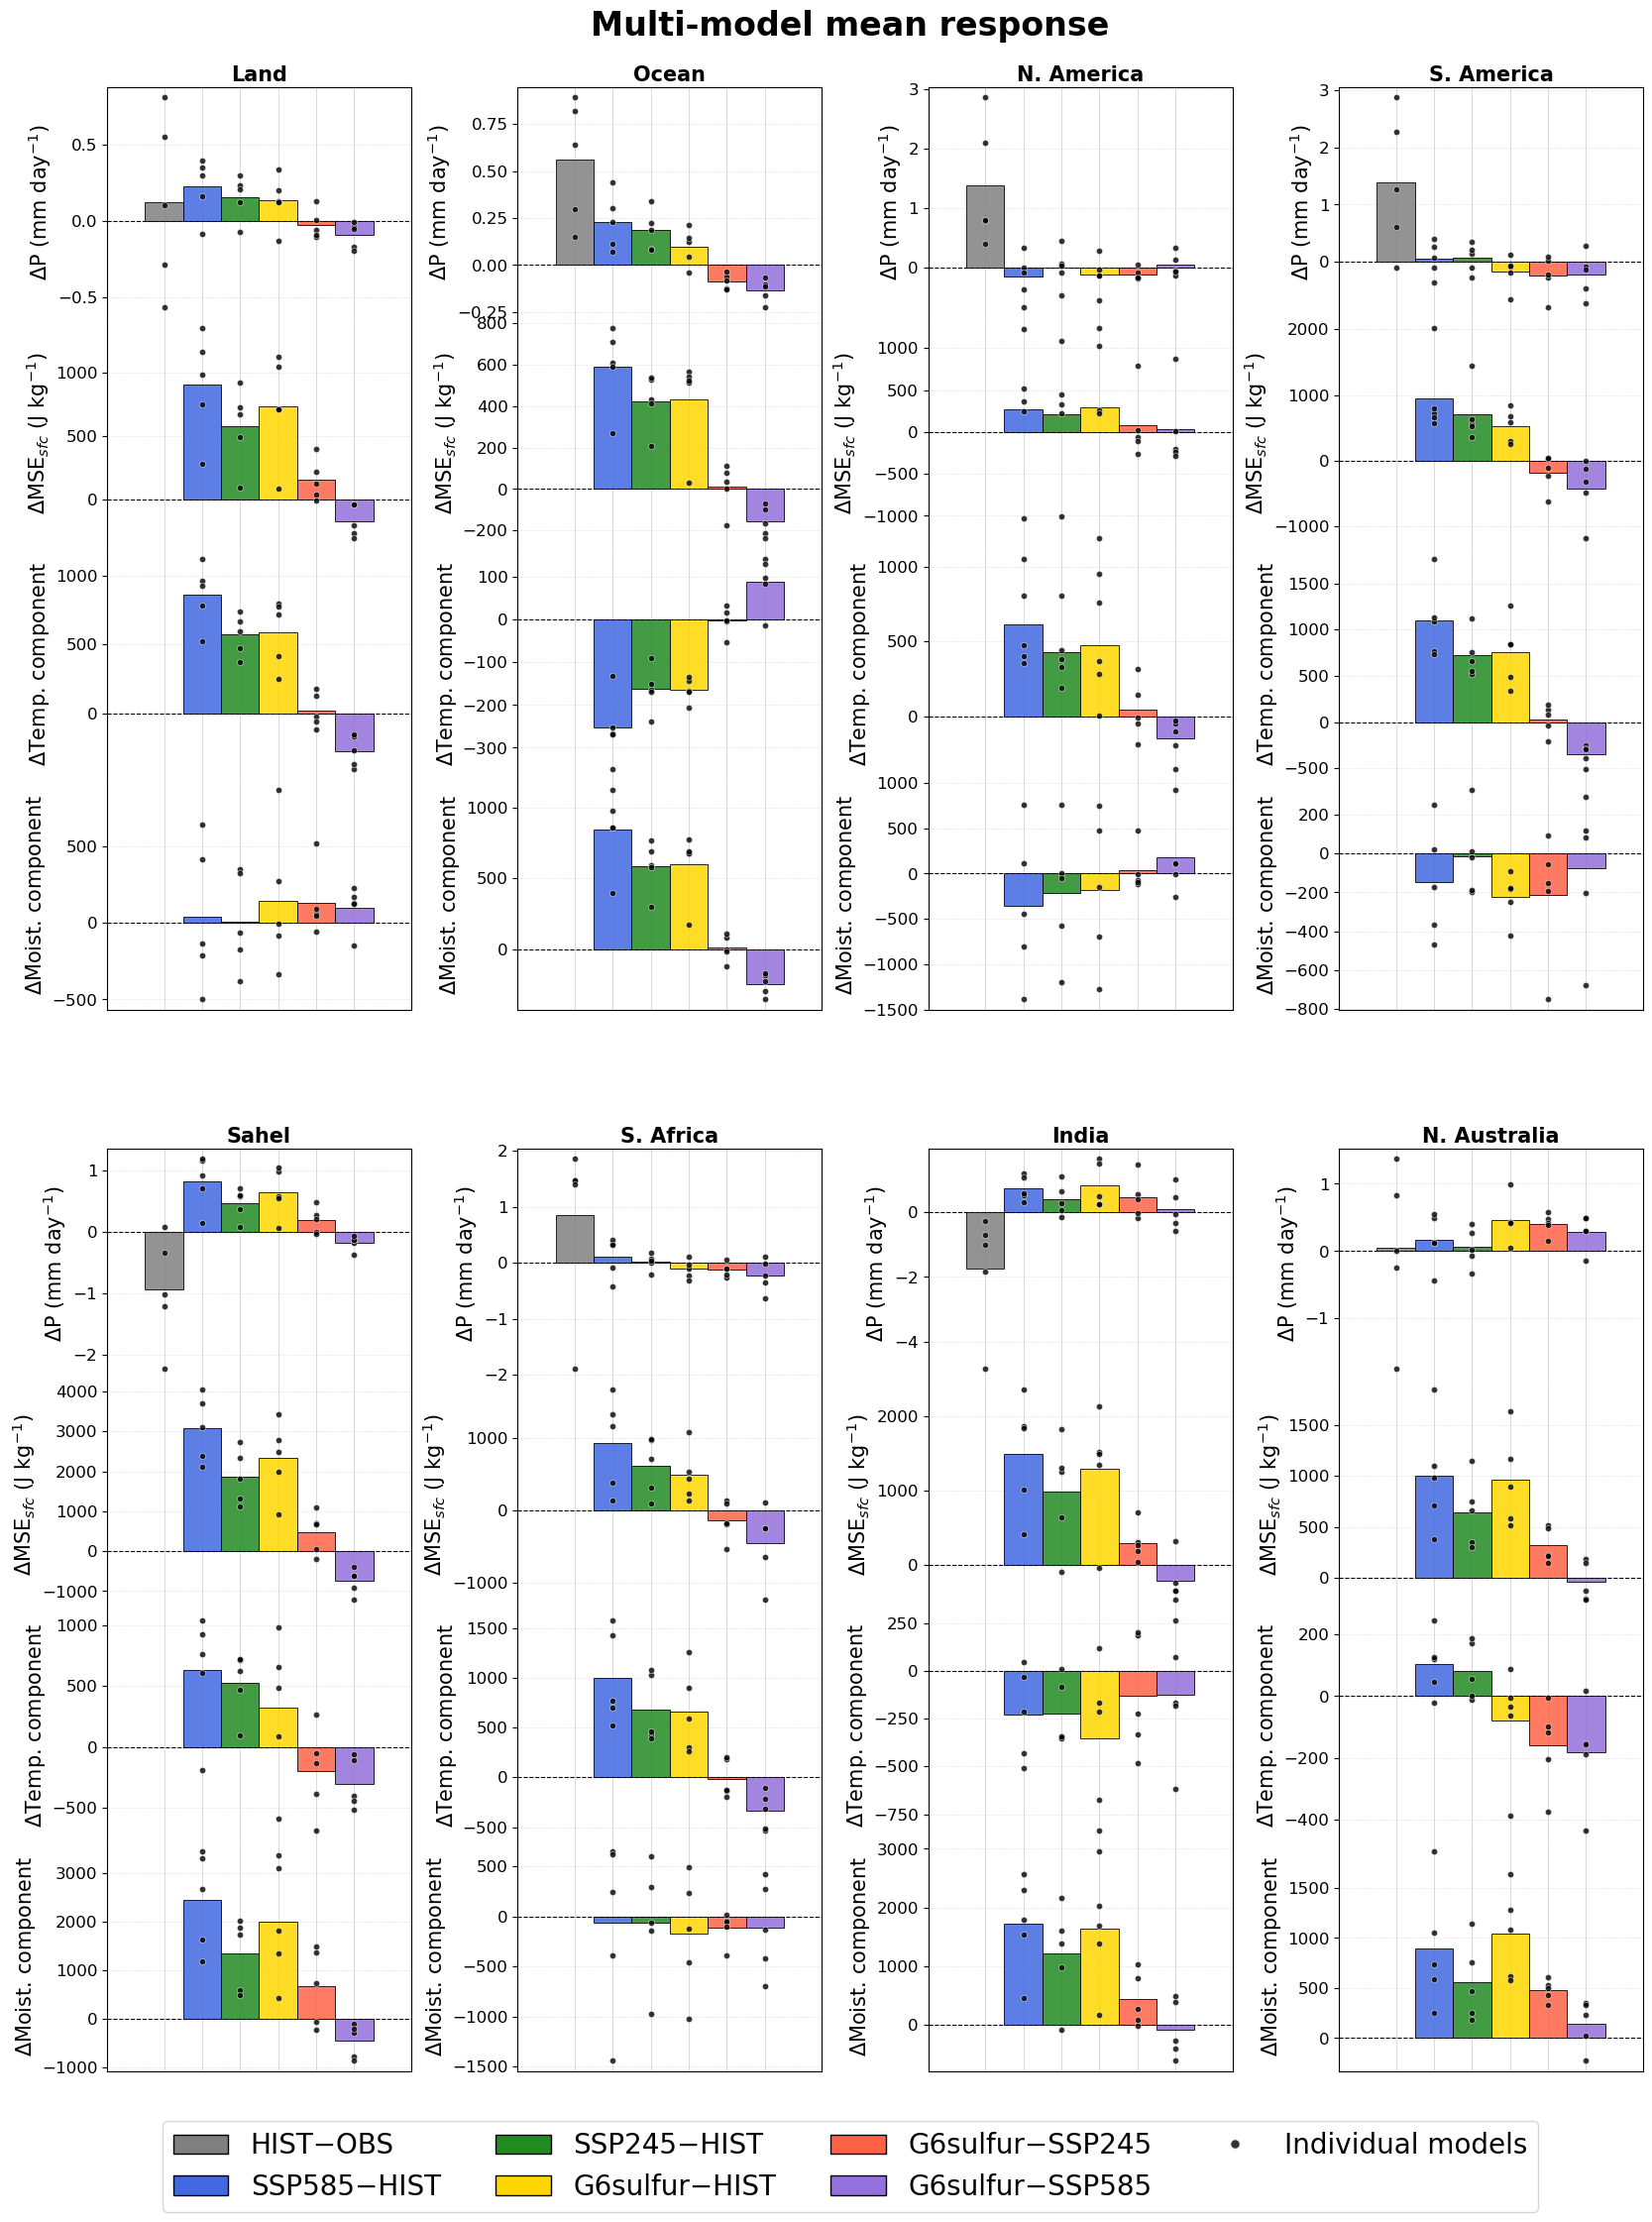

In [5]:


# ── Shared styling ───────────────────────────────────────────────────────────
width     = 0.15
offsets   = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * width
bar_color = ['gray', 'royalblue', 'forestgreen', 'gold', 'tomato', 'mediumpurple']
x = 0

panel_layout = [
    (0, 0, 'Land'),
    (0, 1, 'Ocean'),
    (0, 2, 'N. America'),
    (0, 3, 'S. America'),
    (1, 0, 'Sahel'),
    (1, 1, 'S. Africa'),
    (1, 2, 'India'),
    (1, 3, 'N. Australia'),
]

# ── Per-block dataset definitions ────────────────────────────────────────────
# Each block: list of (data_dict, offset, marker, color, label)
# None in data_dict position = blank bar slot

def make_datasets_rainfall():
    return [
        (bar_data_HIST_TRMM19852014_minus_TRMM,          float(offsets[0]), 'o', bar_color[0], 'HIST−OBS'),
        (bar_data_SSP58520212100_minus_HIST19212000,      float(offsets[1]), 'o', bar_color[1], 'SSP585−HIST'),
        (bar_data_SSP24520212100_minus_HIST19212000,      float(offsets[2]), 'o', bar_color[2], 'SSP245−HIST'),
        (bar_data_G6sulfur20212100_minus_HIST19212000,    float(offsets[3]), 'o', bar_color[3], 'G6sulfur−HIST'),
        (bar_data_G6sulfur20212100_minus_SSP24520212100,  float(offsets[4]), 'o', bar_color[4], 'G6sulfur−SSP245'),
        (bar_data_G6sulfur20212100_minus_SSP58520212100,  float(offsets[5]), 'o', bar_color[5], 'G6sulfur−SSP585'),
    ]

def make_datasets(ssp585, ssp245, g6s_hist, g6s_ssp245, g6s_ssp585):
    return [
        (None,         float(offsets[0]), 'o', bar_color[0], 'HIST−OBS'),       # blank slot
        (ssp585,       float(offsets[1]), 'o', bar_color[1], 'SSP585−HIST'),
        (ssp245,       float(offsets[2]), 'o', bar_color[2], 'SSP245−HIST'),
        (g6s_hist,     float(offsets[3]), 'o', bar_color[3], 'G6sulfur−HIST'),
        (g6s_ssp245,   float(offsets[4]), 'o', bar_color[4], 'G6sulfur−SSP245'),
        (g6s_ssp585,   float(offsets[5]), 'o', bar_color[5], 'G6sulfur−SSP585'),
    ]

blocks = [
    (make_datasets_rainfall(),                                                          '$\\Delta$P (mm day$^{-1}$)'),
    (make_datasets(bar_MSE_SSP585_HIST,  bar_MSE_SSP245_HIST,  bar_MSE_G6s_HIST,  bar_MSE_G6s_SSP245,  bar_MSE_G6s_SSP585),  '$\\Delta$MSE$_{sfc}$ (J kg$^{-1}$)'),
    (make_datasets(bar_var3_SSP585_HIST, bar_var3_SSP245_HIST, bar_var3_G6s_HIST, bar_var3_G6s_SSP245, bar_var3_G6s_SSP585), '$\\Delta$Temp. component'),
    (make_datasets(bar_var4_SSP585_HIST, bar_var4_SSP245_HIST, bar_var4_G6s_HIST, bar_var4_G6s_SSP245, bar_var4_G6s_SSP585), '$\\Delta$Moist. component'),
]

n_blocks  = len(blocks)   # 4
n_rows    = 2
n_cols    = 4

# ── Build figure with nested GridSpec ────────────────────────────────────────
# Outer GridSpec: 2 panel-rows × 4 panel-cols
# Inner GridSpec per cell: 4 sub-rows (one per variable block), no spacing

from matplotlib.gridspec import GridSpecFromSubplotSpec, GridSpec

fig = plt.figure(figsize=(20, 26))
outer_gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.15, wspace=0.35)

all_labels = bar_data_HIST_TRMM19852014_minus_TRMM['labels']

for row, col, panel_label in panel_layout:
    # Inner 4-row grid for this panel
    inner_gs = GridSpecFromSubplotSpec(
        n_blocks, 1,
        subplot_spec=outer_gs[row, col],
        hspace=0.0,   # zero gap between blocks
    )

    try:
        i_label = list(all_labels).index(panel_label)
    except ValueError:
        print(f"Label '{panel_label}' not found, skipping")
        continue

    for b_idx, (datasets, ylabel) in enumerate(blocks):
        ax = fig.add_subplot(inner_gs[b_idx])
        is_top    = (b_idx == 0)
        is_bottom = (b_idx == n_blocks - 1)

        # Gray vertical guide lines
        for offset in offsets:
            ax.axvline(x + offset, color='lightgray', linewidth=0.6,
                       linestyle='-', zorder=1)

        for data, offset, marker, color, leg_label in datasets:
            if data is None:
                continue   # blank slot — leave gap

            val = data['means'][i_label]
            ax.bar(x + offset, val, width=width,
                   color=color, edgecolor='k', linewidth=0.7,
                   alpha=0.85, zorder=3)

            pm_raw = np.array(data['per_model_all'][i_label])
            if pm_raw.ndim == 1:
                pm = pm_raw          # rainfall: already (5,)
            else:
                pm = pm_raw[:, -1]   # MSE/var3/var4: shape (5, 19) → take last timestep
            
            ax.scatter(np.full(len(pm), x + offset), pm,
                       marker=marker, color='k', s=20, zorder=5,
                       alpha=0.8, edgecolors='white', linewidths=0.4)

        ax.axhline(0, color='k', linewidth=0.8, linestyle='--', zorder=2)
        ax.set_xlim(-0.6, 0.6)
        ax.set_xticks([])
        ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.6, zorder=0)

        # Y-axis label on left
        ax.set_ylabel(ylabel, fontsize=15, labelpad=3)
        ax.tick_params(axis='y', labelsize=12)

        # Title only on top block
        if is_top:
            ax.set_title(panel_label, fontsize=15, fontweight='bold', pad=4)

        # Remove top/bottom spines between blocks for clean stacking
        if not is_top:
            ax.spines['top'].set_visible(False)
        if not is_bottom:
            ax.spines['bottom'].set_visible(False)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor=bar_color[0], edgecolor='k', label='HIST−OBS'),
    mpatches.Patch(facecolor=bar_color[1], edgecolor='k', label='SSP585−HIST'),
    mpatches.Patch(facecolor=bar_color[2], edgecolor='k', label='SSP245−HIST'),
    mpatches.Patch(facecolor=bar_color[3], edgecolor='k', label='G6sulfur−HIST'),
    mpatches.Patch(facecolor=bar_color[4], edgecolor='k', label='G6sulfur−SSP245'),
    mpatches.Patch(facecolor=bar_color[5], edgecolor='k', label='G6sulfur−SSP585'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
               markersize=7, alpha=0.8, label='Individual models'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=20, bbox_to_anchor=(0.5, 0.05))

plt.suptitle('Multi-model mean response', fontsize=24, fontweight='bold', y=0.91)
plt.savefig("Rain_MSE_T_Q_Combined_panels.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot only for monsoon regions and G6-245 and G6-585

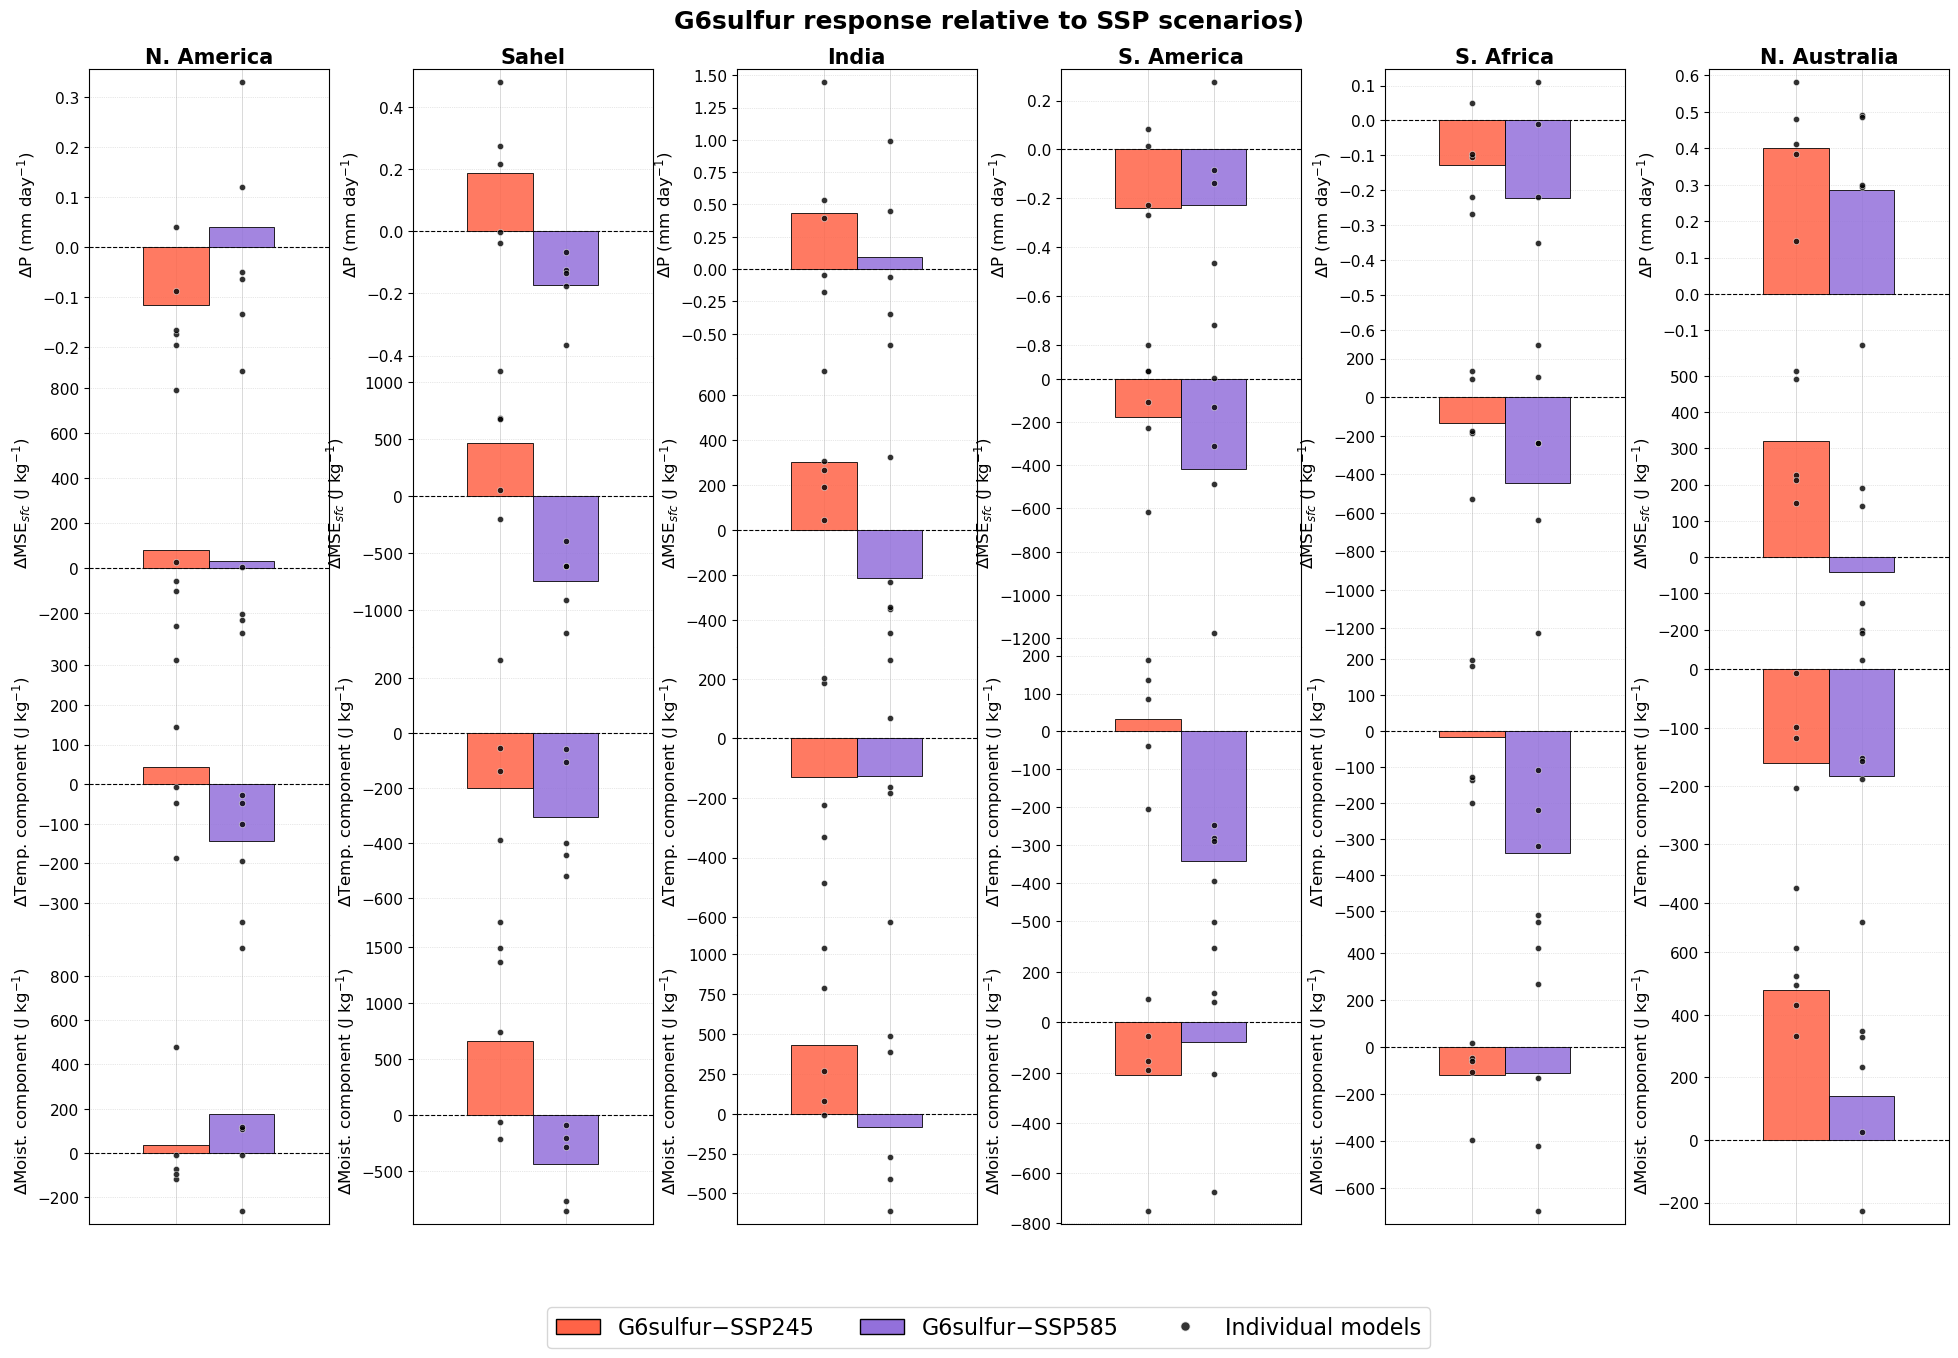

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpecFromSubplotSpec, GridSpec

# ── Shared styling ───────────────────────────────────────────────────────────
width     = 0.15
# Only 2 scenarios + 1 blank = 3 bars, re-center offsets
offsets   = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * width  # keep same so blank aligns
bar_color = ['gray', 'royalblue', 'forestgreen', 'gold', 'tomato', 'mediumpurple']
x = 0

#For 2x3
# # ── Only monsoon regions, NH top / SH bottom ────────────────────────────────
# panel_layout = [
#     (0, 0, 'N. America'),   # NH monsoons
#     (0, 1, 'Sahel'),
#     (0, 2, 'India'),
#     (1, 0, 'S. America'),   # SH monsoons
#     (1, 1, 'S. Africa'),
#     (1, 2, 'N. Australia'),
# ]

#For 1x6
panel_layout = [
    (0, 0, 'N. America'),
    (0, 1, 'Sahel'),
    (0, 2, 'India'),
    (0, 3, 'S. America'),
    (0, 4, 'S. Africa'),
    (0, 5, 'N. Australia'),
]

# ── Dataset builders — only G6-SSP245 and G6-SSP585 ─────────────────────────
def make_datasets_rainfall():
    return [
        (None,                                           float(offsets[0]), 'o', bar_color[0], 'HIST−OBS'),       # blank
        (None,                                           float(offsets[1]), 'o', bar_color[1], 'SSP585−HIST'),    # blank
        (None,                                           float(offsets[2]), 'o', bar_color[2], 'SSP245−HIST'),    # blank
        (None,                                           float(offsets[3]), 'o', bar_color[3], 'G6sulfur−HIST'),  # blank
        (bar_data_G6sulfur20212100_minus_SSP24520212100, float(offsets[4]), 'o', bar_color[4], 'G6sulfur−SSP245'),
        (bar_data_G6sulfur20212100_minus_SSP58520212100, float(offsets[5]), 'o', bar_color[5], 'G6sulfur−SSP585'),
    ]

def make_datasets(g6s_ssp245, g6s_ssp585):
    return [
        (None,       float(offsets[0]), 'o', bar_color[0], 'HIST−OBS'),
        (None,       float(offsets[1]), 'o', bar_color[1], 'SSP585−HIST'),
        (None,       float(offsets[2]), 'o', bar_color[2], 'SSP245−HIST'),
        (None,       float(offsets[3]), 'o', bar_color[3], 'G6sulfur−HIST'),
        (g6s_ssp245, float(offsets[4]), 'o', bar_color[4], 'G6sulfur−SSP245'),
        (g6s_ssp585, float(offsets[5]), 'o', bar_color[5], 'G6sulfur−SSP585'),
    ]

# blocks = [ ;#For %
#     (make_datasets_rainfall(),
#      '$\\Delta$P (mm day$^{-1}$)',
#      None),

#     (make_datasets(bar_MSE_G6s_SSP245, bar_MSE_G6s_SSP585),
#      '$\\Delta$MSE$_{sfc}$ (J kg$^{-1}$)',
#      None),

#     (make_datasets(bar_var3_G6s_SSP245, bar_var3_G6s_SSP585),
#      'Temp. component (% MSE)',
#      [None, None, None, None, bar_MSE_G6s_SSP245, bar_MSE_G6s_SSP585]),

#     (make_datasets(bar_var4_G6s_SSP245, bar_var4_G6s_SSP585),
#      'Moist. component (% MSE)',
#      [None, None, None, None, bar_MSE_G6s_SSP245, bar_MSE_G6s_SSP585]),
# ]

blocks = [
    (make_datasets_rainfall(),
     '$\\Delta$P (mm day$^{-1}$)',
     None),

    (make_datasets(bar_MSE_G6s_SSP245, bar_MSE_G6s_SSP585),
     '$\\Delta$MSE$_{sfc}$ (J kg$^{-1}$)',
     None),

    (make_datasets(bar_var3_G6s_SSP245, bar_var3_G6s_SSP585),
     '$\\Delta$Temp. component (J kg$^{-1}$)',
     None),

    (make_datasets(bar_var4_G6s_SSP245, bar_var4_G6s_SSP585),
     '$\\Delta$Moist. component (J kg$^{-1}$)',
     None),
]

n_blocks = len(blocks)
n_rows   = 1
n_cols   = 6

# ── Figure ───────────────────────────────────────────────────────────────────
if n_cols == 3:
    fig = plt.figure(figsize=(16, 26))

if n_cols == 6:
    fig = plt.figure(figsize=(24, 15))

outer_gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.15, wspace=0.35)

all_labels = bar_data_HIST_TRMM19852014_minus_TRMM['labels']

for row, col, panel_label in panel_layout:
    inner_gs = GridSpecFromSubplotSpec(
        n_blocks, 1,
        subplot_spec=outer_gs[row, col],
        hspace=0.0,
    )
    try:
        i_label = list(all_labels).index(panel_label)
    except ValueError:
        print(f"Label '{panel_label}' not found, skipping")
        continue

    # for b_idx, (datasets, ylabel, pct_refs) in enumerate(blocks): ;#For %
    for b_idx, (datasets, ylabel, _) in enumerate(blocks):
        ax = fig.add_subplot(inner_gs[b_idx])
        is_top    = (b_idx == 0)
        is_bottom = (b_idx == n_blocks - 1)

        # Only draw guide lines for active bar positions
        for offset in [float(offsets[4]), float(offsets[5])]:
            ax.axvline(x + offset, color='lightgray', linewidth=0.6,
                       linestyle='-', zorder=1)

        # for d_idx, (data, offset, marker, color, leg_label) in enumerate(datasets): ;#For %
        #     if data is None:
        #         continue

        #     if pct_refs is not None:
        #         mse_ref = pct_refs[d_idx]
        #         val = (data['means'][i_label] / mse_ref['means'][i_label]) * 100
        #     else:
        #         val = data['means'][i_label]

        #     ax.bar(x + offset, val, width=width,
        #            color=color, edgecolor='k', linewidth=0.7,
        #            alpha=0.85, zorder=3)

        #     pm_raw = np.array(data['per_model_all'][i_label])
        #     pm = pm_raw if pm_raw.ndim == 1 else pm_raw[:, -1]

        #     if pct_refs is not None:
        #         mse_ref = pct_refs[d_idx]
        #         mse_pm_raw = np.array(mse_ref['per_model_all'][i_label])
        #         mse_pm = mse_pm_raw if mse_pm_raw.ndim == 1 else mse_pm_raw[:, -1]
        #         pm = (pm / mse_pm) * 100

        #     ax.scatter(np.full(len(pm), x + offset), pm,
        #                marker=marker, color='k', s=20, zorder=5,
        #                alpha=0.8, edgecolors='white', linewidths=0.4)

        for d_idx, (data, offset, marker, color, leg_label) in enumerate(datasets):
            if data is None:
                continue
        
            val = data['means'][i_label]   # always raw
            ax.bar(x + offset, val, width=width,
                   color=color, edgecolor='k', linewidth=0.7,
                   alpha=0.85, zorder=3)
        
            pm_raw = np.array(data['per_model_all'][i_label])
            pm = pm_raw if pm_raw.ndim == 1 else pm_raw[:, -1]
        
            ax.scatter(np.full(len(pm), x + offset), pm,
                       marker=marker, color='k', s=20, zorder=5,
                       alpha=0.8, edgecolors='white', linewidths=0.4)

        ax.axhline(0, color='k', linewidth=0.8, linestyle='--', zorder=2)
        # if pct_refs is not None:
        #     ax.axhline( 100, color='gray', linewidth=0.6, linestyle=':', zorder=2)
        #     ax.axhline(-100, color='gray', linewidth=0.6, linestyle=':', zorder=2)

        # Tighten x-axis to just show the two active bars
        ax.set_xlim(float(offsets[4]) - 0.2, float(offsets[5]) + 0.2)
        ax.set_xticks([])
        ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.6, zorder=0)
        ax.set_ylabel(ylabel, fontsize=12, labelpad=3)
        ax.tick_params(axis='y', labelsize=11)

        if is_top:
            ax.set_title(panel_label, fontsize=15, fontweight='bold', pad=4)

        if not is_top:
            ax.spines['top'].set_visible(False)
        if not is_bottom:
            ax.spines['bottom'].set_visible(False)

# ── Row labels ───────────────────────────────────────────────────────────────
if n_cols == 3:
    fig.text(0.01, 0.73, 'NH Monsoons', fontsize=16, fontweight='bold',
             va='center', rotation='vertical', color='darkblue')
    fig.text(0.01, 0.30, 'SH Monsoons', fontsize=16, fontweight='bold',
             va='center', rotation='vertical', color='darkgreen')

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor=bar_color[4], edgecolor='k', label='G6sulfur−SSP245'),
    mpatches.Patch(facecolor=bar_color[5], edgecolor='k', label='G6sulfur−SSP585'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
               markersize=7, alpha=0.8, label='Individual models'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=16, bbox_to_anchor=(0.5, 0.02))

# plt.suptitle('G6sulfur response relative to SSP scenarios\n(NH monsoons top, SH monsoons bottom)',
#              fontsize=18, fontweight='bold', y=0.93)

plt.suptitle('G6sulfur response relative to SSP scenarios)',
             fontsize=18, fontweight='bold', y=0.92)

# plt.savefig("G6_Monsoon_panels.png", dpi=150, bbox_inches="tight")
plt.savefig("Rain_MSE_T_Q_G6_Monsoon_panels.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
def make_datasets_pct(ssp585, ssp245, g6s_hist, g6s_ssp245, g6s_ssp585,
                      mse_ssp585, mse_ssp245, mse_g6s_hist, mse_g6s_ssp245, mse_g6s_ssp585):
    """Like make_datasets but values expressed as % of corresponding MSE."""
    raw = [
        (None,       None,         float(offsets[0]), 'o', bar_color[0], 'HIST−OBS'),
        (ssp585,     mse_ssp585,   float(offsets[1]), 'o', bar_color[1], 'SSP585−HIST'),
        (ssp245,     mse_ssp245,   float(offsets[2]), 'o', bar_color[2], 'SSP245−HIST'),
        (g6s_hist,   mse_g6s_hist, float(offsets[3]), 'o', bar_color[3], 'G6sulfur−HIST'),
        (g6s_ssp245, mse_g6s_ssp245, float(offsets[4]), 'o', bar_color[4], 'G6sulfur−SSP245'),
        (g6s_ssp585, mse_g6s_ssp585, float(offsets[5]), 'o', bar_color[5], 'G6sulfur−SSP585'),
    ]
    return raw

In [7]:
# blocks = [
#     (make_datasets_rainfall(),   '$\\Delta$P (mm day$^{-1}$)',        None),
#     (make_datasets(bar_MSE_SSP585_HIST, bar_MSE_SSP245_HIST,
#                    bar_MSE_G6s_HIST, bar_MSE_G6s_SSP245,
#                    bar_MSE_G6s_SSP585),
#                    '$\\Delta$MSE$_{sfc}$ (J kg$^{-1}$)',              None),
#     (make_datasets(bar_var3_SSP585_HIST, bar_var3_SSP245_HIST,
#                    bar_var3_G6s_HIST, bar_var3_G6s_SSP245,
#                    bar_var3_G6s_SSP585),
#                    'Temp. component (% MSE)',
#                    # pct_ref: MSE datasets in same order as datasets list
#                    [None, bar_MSE_SSP585_HIST, bar_MSE_SSP245_HIST,
#                     bar_MSE_G6s_HIST, bar_MSE_G6s_SSP245, bar_MSE_G6s_SSP585]),
#     (make_datasets(bar_var4_SSP585_HIST, bar_var4_SSP245_HIST,
#                    bar_var4_G6s_HIST, bar_var4_G6s_SSP245,
#                    bar_var4_G6s_SSP585),
#                    'Moist. component (% MSE)',
#                    [None, bar_MSE_SSP585_HIST, bar_MSE_SSP245_HIST,
#                     bar_MSE_G6s_HIST, bar_MSE_G6s_SSP245, bar_MSE_G6s_SSP585]),
# ]

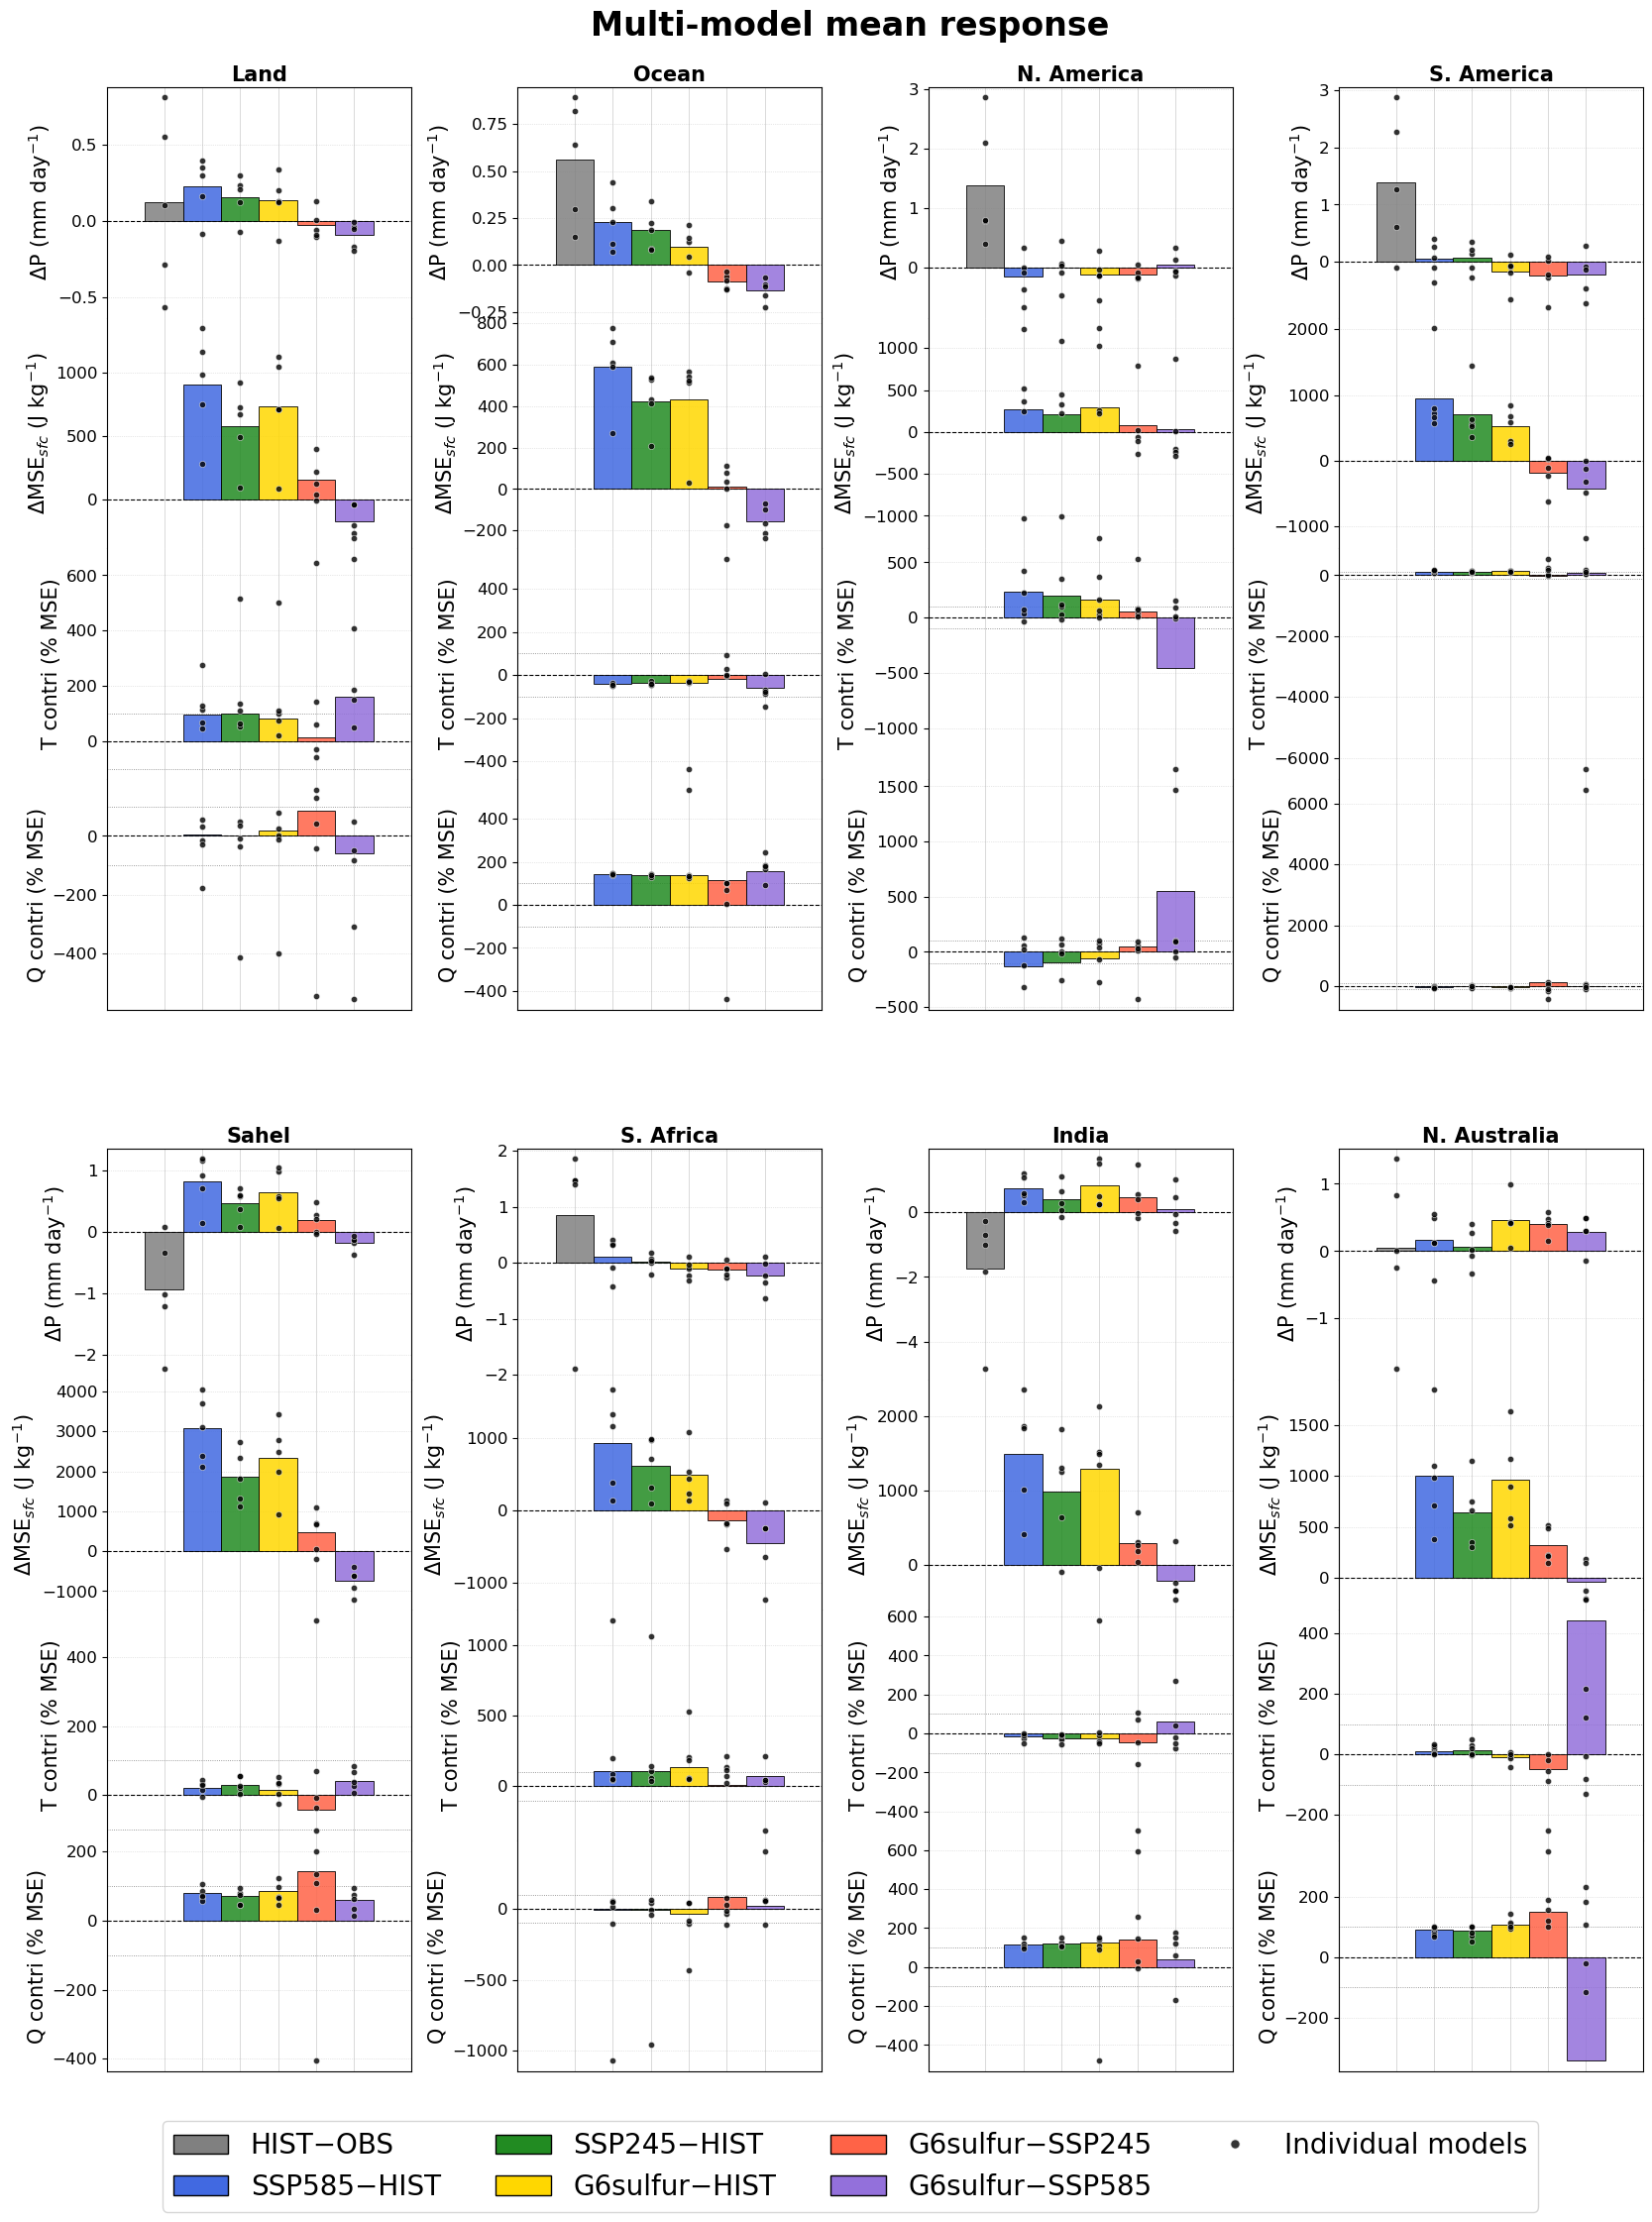

In [8]:
# ── Shared styling ───────────────────────────────────────────────────────────
width     = 0.15
offsets   = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * width
bar_color = ['gray', 'royalblue', 'forestgreen', 'gold', 'tomato', 'mediumpurple']
x = 0

def make_datasets_rainfall():
    return [
        (bar_data_HIST_TRMM19852014_minus_TRMM,         float(offsets[0]), 'o', bar_color[0], 'HIST−OBS'),
        (bar_data_SSP58520212100_minus_HIST19212000,     float(offsets[1]), 'o', bar_color[1], 'SSP585−HIST'),
        (bar_data_SSP24520212100_minus_HIST19212000,     float(offsets[2]), 'o', bar_color[2], 'SSP245−HIST'),
        (bar_data_G6sulfur20212100_minus_HIST19212000,   float(offsets[3]), 'o', bar_color[3], 'G6sulfur−HIST'),
        (bar_data_G6sulfur20212100_minus_SSP24520212100, float(offsets[4]), 'o', bar_color[4], 'G6sulfur−SSP245'),
        (bar_data_G6sulfur20212100_minus_SSP58520212100, float(offsets[5]), 'o', bar_color[5], 'G6sulfur−SSP585'),
    ]

def make_datasets(ssp585, ssp245, g6s_hist, g6s_ssp245, g6s_ssp585):
    return [
        (None,       float(offsets[0]), 'o', bar_color[0], 'HIST−OBS'),
        (ssp585,     float(offsets[1]), 'o', bar_color[1], 'SSP585−HIST'),
        (ssp245,     float(offsets[2]), 'o', bar_color[2], 'SSP245−HIST'),
        (g6s_hist,   float(offsets[3]), 'o', bar_color[3], 'G6sulfur−HIST'),
        (g6s_ssp245, float(offsets[4]), 'o', bar_color[4], 'G6sulfur−SSP245'),
        (g6s_ssp585, float(offsets[5]), 'o', bar_color[5], 'G6sulfur−SSP585'),
    ]

# ONE blocks definition — 3-tuple: (datasets, ylabel, pct_refs or None)
blocks = [
    (make_datasets_rainfall(),
     '$\\Delta$P (mm day$^{-1}$)',
     None),

    (make_datasets(bar_MSE_SSP585_HIST, bar_MSE_SSP245_HIST,
                   bar_MSE_G6s_HIST, bar_MSE_G6s_SSP245, bar_MSE_G6s_SSP585),
     '$\\Delta$MSE$_{sfc}$ (J kg$^{-1}$)',
     None),

    (make_datasets(bar_var3_SSP585_HIST, bar_var3_SSP245_HIST,
                   bar_var3_G6s_HIST, bar_var3_G6s_SSP245, bar_var3_G6s_SSP585),
     'T contri (% MSE)',
     [None, bar_MSE_SSP585_HIST, bar_MSE_SSP245_HIST,
      bar_MSE_G6s_HIST, bar_MSE_G6s_SSP245, bar_MSE_G6s_SSP585]),

    (make_datasets(bar_var4_SSP585_HIST, bar_var4_SSP245_HIST,
                   bar_var4_G6s_HIST, bar_var4_G6s_SSP245, bar_var4_G6s_SSP585),
     'Q contri (% MSE)',
     [None, bar_MSE_SSP585_HIST, bar_MSE_SSP245_HIST,
      bar_MSE_G6s_HIST, bar_MSE_G6s_SSP245, bar_MSE_G6s_SSP585]),
]

n_blocks = len(blocks)  # 4
n_rows   = 2
n_cols   = 4

# ── Build figure with nested GridSpec ────────────────────────────────────────
# Outer GridSpec: 2 panel-rows × 4 panel-cols
# Inner GridSpec per cell: 4 sub-rows (one per variable block), no spacing

from matplotlib.gridspec import GridSpecFromSubplotSpec, GridSpec

fig = plt.figure(figsize=(20, 26))
outer_gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.15, wspace=0.35)
all_labels = bar_data_HIST_TRMM19852014_minus_TRMM['labels']

for row, col, panel_label in panel_layout:
    inner_gs = GridSpecFromSubplotSpec(
        n_blocks, 1,
        subplot_spec=outer_gs[row, col],
        hspace=0.0,
    )
    try:
        i_label = list(all_labels).index(panel_label)
    except ValueError:
        print(f"Label '{panel_label}' not found, skipping")
        continue

    for b_idx, (datasets, ylabel, pct_refs) in enumerate(blocks):  # <-- unpack 3
        ax = fig.add_subplot(inner_gs[b_idx])
        is_top    = (b_idx == 0)
        is_bottom = (b_idx == n_blocks - 1)

        for offset in offsets:
            ax.axvline(x + offset, color='lightgray', linewidth=0.6,
                       linestyle='-', zorder=1)

        for d_idx, (data, offset, marker, color, leg_label) in enumerate(datasets):
            if data is None:
                continue

            # ── value (normalize to % of MSE if pct_refs given) ──
            if pct_refs is not None:
                mse_ref = pct_refs[d_idx]
                val = (data['means'][i_label] / mse_ref['means'][i_label]) * 100
            else:
                val = data['means'][i_label]

            ax.bar(x + offset, val, width=width,
                   color=color, edgecolor='k', linewidth=0.7,
                   alpha=0.85, zorder=3)

            # ── per-model scatter ──
            pm_raw = np.array(data['per_model_all'][i_label])
            pm = pm_raw if pm_raw.ndim == 1 else pm_raw[:, -1]

            if pct_refs is not None:
                mse_ref = pct_refs[d_idx]
                mse_pm_raw = np.array(mse_ref['per_model_all'][i_label])
                mse_pm = mse_pm_raw if mse_pm_raw.ndim == 1 else 0 ;#mse_pm_raw[:, -1]
                pm = (pm / mse_pm) * 100

            ax.scatter(np.full(len(pm), x + offset), pm,
                       marker=marker, color='k', s=20, zorder=5,
                       alpha=0.8, edgecolors='white', linewidths=0.4)

        ax.axhline(0, color='k', linewidth=0.8, linestyle='--', zorder=2)
        if pct_refs is not None:
            ax.axhline(100,  color='gray', linewidth=0.6, linestyle=':', zorder=2)
            ax.axhline(-100, color='gray', linewidth=0.6, linestyle=':', zorder=2)

        ax.set_xlim(-0.6, 0.6)
        ax.set_xticks([])
        ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.6, zorder=0)
        ax.set_ylabel(ylabel, fontsize=15, labelpad=3)
        ax.tick_params(axis='y', labelsize=12)

        if is_top:
            ax.set_title(panel_label, fontsize=15, fontweight='bold', pad=4)

        if not is_top:
            ax.spines['top'].set_visible(False)
        if not is_bottom:
            ax.spines['bottom'].set_visible(False)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor=bar_color[0], edgecolor='k', label='HIST−OBS'),
    mpatches.Patch(facecolor=bar_color[1], edgecolor='k', label='SSP585−HIST'),
    mpatches.Patch(facecolor=bar_color[2], edgecolor='k', label='SSP245−HIST'),
    mpatches.Patch(facecolor=bar_color[3], edgecolor='k', label='G6sulfur−HIST'),
    mpatches.Patch(facecolor=bar_color[4], edgecolor='k', label='G6sulfur−SSP245'),
    mpatches.Patch(facecolor=bar_color[5], edgecolor='k', label='G6sulfur−SSP585'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
               markersize=7, alpha=0.8, label='Individual models'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=20, bbox_to_anchor=(0.5, 0.05))

plt.suptitle('Multi-model mean response', fontsize=24, fontweight='bold', y=0.91)
plt.savefig("Rain_MSE_T_Q_Combined_panels_percent.png", dpi=150, bbox_inches="tight")
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

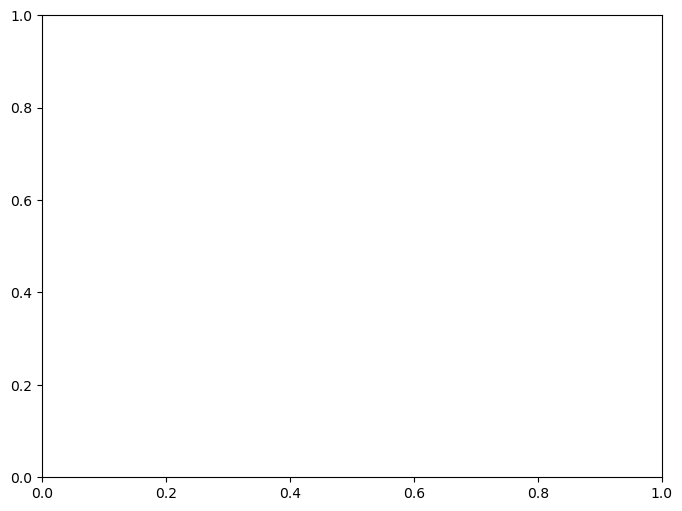

In [9]:
# panel_layout = [
#     (0, 0, 'Land'),
#     (0, 1, 'Ocean'),
#     (0, 2, 'N. America'),
#     (0, 3, 'S. America'),
#     (1, 0, 'Sahel'),
#     (1, 1, 'S. Africa'),
#     (1, 2, 'India'),
#     (1, 3, 'N. Australia'),
# ]


import numpy as np
import matplotlib.pyplot as plt

# ── Pair up rainfall and MSE datasets by scenario ───────────────────────────
scenario_pairs = [
    (bar_data_SSP58520212100_minus_HIST19212000,     bar_MSE_SSP585_HIST,  'royalblue',    'SSP585−HIST',     's'),
    (bar_data_SSP24520212100_minus_HIST19212000,     bar_MSE_SSP245_HIST,  'forestgreen',  'SSP245−HIST',     'o'),
    (bar_data_G6sulfur20212100_minus_HIST19212000,   bar_MSE_G6s_HIST,     'gold',         'G6sulfur−HIST',   'D'),
    (bar_data_G6sulfur20212100_minus_SSP24520212100, bar_MSE_G6s_SSP245,   'tomato',       'G6sulfur−SSP245', '^'),
    (bar_data_G6sulfur20212100_minus_SSP58520212100, bar_MSE_G6s_SSP585,   'mediumpurple', 'G6sulfur−SSP585', 'X'),
]

region_labels = list(bar_data_SSP58520212100_minus_HIST19212000['labels'])

# region = 'N. Australia'   # or 'Land', 'Sahel', etc.
# i_label = region_labels.index(region)
i_label = region_labels

fig, ax = plt.subplots(figsize=(8, 6))

for rain_data, mse_data, color, label, marker in scenario_pairs:
    rain_vals = np.array(rain_data['means'])[i_label]     # shape (n_regions,)
    mse_vals  = np.array(mse_data['means'])[i_label]      # shape (n_regions,)

    sc = ax.scatter(mse_vals, rain_vals,
                    color=color, marker=marker,
                    s=80, edgecolors='k', linewidths=0.6,
                    zorder=4, label=label)

    # # Annotate each point with region name
    # for i, reg in enumerate(region_labels):
    #     # if reg != "India":
    #     #     continue
    #     ax.annotate(reg, (mse_vals[i], rain_vals[i]),
    #                 fontsize=7, textcoords='offset points',
    #                 xytext=(5, 3), color=color)

ax.axhline(0, color='k', linewidth=0.7, linestyle='--', zorder=2)
ax.axvline(0, color='k', linewidth=0.7, linestyle='--', zorder=2)

ax.set_xlabel('$\\Delta$MSE$_{sfc}$ (J kg$^{-1}$)', fontsize=11)
ax.set_ylabel('$\\Delta$P (mm day$^{-1}$)', fontsize=11)
ax.set_title('Rainfall vs MSE$_{sfc}$ anomalies across regions', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.8)
ax.grid(linestyle=':', linewidth=0.6, alpha=0.6)

plt.tight_layout()
# plt.savefig("Scatter_Rain_vs_MSE.png", dpi=150, bbox_inches="tight")
plt.show()